<a href="https://colab.research.google.com/github/Chetalam/cnn-skin-cancer-classification/blob/main/notebooks/02_exploratory_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis

## Objective
Explore the selected Melanoma, BCC and SCC records from HAM10000
and PAD-UFES-20 before data cleaning and model development.

## Input
The SQLite database created in 01_database_setup.ipynb.

## Analysis
- Dataset and class distributions
- Missing metadata and repeated identifiers
- Age and recorded sex/gender values
- Multiple images belonging to the same lesion or patient
- Image readability, dimensions and colour modes
- Representative images

This notebook preserves the original database and image files.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from IPython.display import display

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/cnn-skin-cancer-classification"
)
DB_PATH = PROJECT_ROOT / "Database" / "skin_cancer.db"

# EDA reports are saved separately from datasets and database.
OUTPUT_ROOT = PROJECT_ROOT / "Reports" / "EDA"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

if not DB_PATH.is_file():
    raise FileNotFoundError(f"Database not found: {DB_PATH}")

CLASS_ORDER = ["Melanoma", "BCC", "SCC"]
DATASET_ORDER = ["HAM10000", "PAD-UFES-20"]

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
})

def save_chart(fig, filename):
    fig.savefig(
        OUTPUT_ROOT / filename,
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)

print("Database:", DB_PATH)
print("Reports:", OUTPUT_ROOT)

Mounted at /content/drive
Database: /content/drive/MyDrive/cnn-skin-cancer-classification/Database/skin_cancer.db
Reports: /content/drive/MyDrive/cnn-skin-cancer-classification/Reports/EDA


In [2]:
# Read-only mode prevents accidental database changes.
with sqlite3.connect(
    DB_PATH.as_uri() + "?mode=ro", uri=True
) as conn:
    integrity = conn.execute(
        "PRAGMA integrity_check"
    ).fetchone()[0]

    if integrity != "ok":
        raise RuntimeError(f"Database integrity: {integrity}")

    df = pd.read_sql_query("SELECT * FROM images", conn)

required_columns = {
    "dataset", "image_id", "lesion_id", "patient_id",
    "class_label", "age", "sex", "localization", "image_path"
}

missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Missing columns: {missing_columns}")

if df.empty:
    raise ValueError("The images table is empty.")

if not df["class_label"].isin(CLASS_ORDER).all():
    raise ValueError("Unexpected or missing class labels.")

if not df["dataset"].isin(DATASET_ORDER).all():
    raise ValueError("Unexpected or missing dataset names.")

df["age"] = pd.to_numeric(df["age"], errors="coerce")

print("Database integrity:", integrity)
print("Selected image records:", len(df))
print("Expected records from database setup: 2716")
display(df.head())

Database integrity: ok
Selected image records: 2716
Expected records from database setup: 2716


,id,dataset,image_id,lesion_id,patient_id,original_label,class_label,age,sex,localization,image_path
0,1,HAM10000,ISIC_0025964,HAM_0000871,None,mel,Melanoma,40.0,female,chest,/content/drive/MyDrive/cnn-skin-cancer-classif...
1,2,HAM10000,ISIC_0030623,HAM_0000871,None,mel,Melanoma,40.0,female,chest,/content/drive/MyDrive/cnn-skin-cancer-classif...
2,3,HAM10000,ISIC_0027190,HAM_0000040,None,mel,Melanoma,80.0,male,upper extremity,/content/drive/MyDrive/cnn-skin-cancer-classif...
3,4,HAM10000,ISIC_0031023,HAM_0005678,None,mel,Melanoma,60.0,male,chest,/content/drive/MyDrive/cnn-skin-cancer-classif...
4,5,HAM10000,ISIC_0028086,HAM_0005678,None,mel,Melanoma,60.0,male,chest,/content/drive/MyDrive/cnn-skin-cancer-classif...


,image_count,percentage
class_label,,
Melanoma,1165,42.89
BCC,1359,50.04
SCC,192,7.07


dataset,HAM10000,PAD-UFES-20
class_label,,
Melanoma,1113,52
BCC,514,845
SCC,0,192


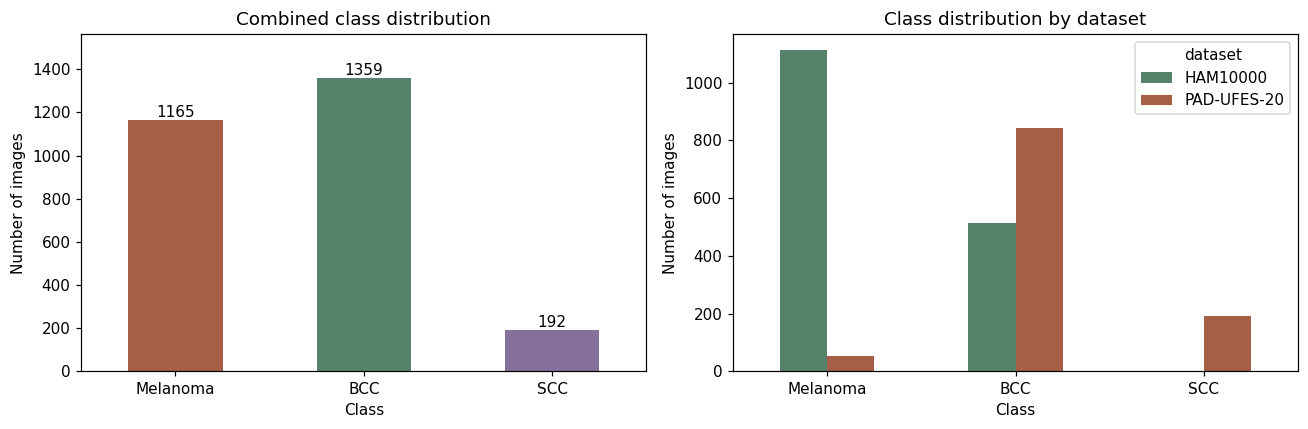

In [3]:
class_counts = df["class_label"].value_counts().reindex(
    CLASS_ORDER, fill_value=0
)

class_summary = pd.DataFrame({
    "image_count": class_counts,
    "percentage": (class_counts / len(df) * 100).round(2)
})

source_summary = pd.crosstab(
    df["class_label"], df["dataset"]
).reindex(
    index=CLASS_ORDER,
    columns=DATASET_ORDER,
    fill_value=0
)

display(class_summary)
display(source_summary)

class_summary.to_csv(OUTPUT_ROOT / "class_distribution.csv")
source_summary.to_csv(OUTPUT_ROOT / "class_by_dataset.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

class_counts.plot.bar(
    ax=axes[0],
    color=["#a65e46", "#56816b", "#84709b"]
)
axes[0].set_title("Combined class distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of images")
axes[0].tick_params(axis="x", rotation=0)
axes[0].set_ylim(0, class_counts.max() * 1.15)

for i, count in enumerate(class_counts):
    axes[0].text(
        i, count, str(count),
        ha="center", va="bottom"
    )

source_summary.plot.bar(
    ax=axes[1],
    color=["#56816b", "#a65e46"]
)
axes[1].set_title("Class distribution by dataset")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of images")
axes[1].tick_params(axis="x", rotation=0)

fig.tight_layout()
save_chart(fig, "01_class_distribution.png")

Missing metadata:


,missing_count,missing_percentage
id,0,0.00
dataset,0,0.00
image_id,0,0.00
lesion_id,0,0.00
patient_id,1627,59.90
original_label,0,0.00
class_label,0,0.00
age,2,0.07
sex,0,0.00
localization,0,0.00


Missing counts by dataset:


,patient_id,lesion_id,age,sex,localization
dataset,,,,,
HAM10000,1627,0,2,0,0
PAD-UFES-20,0,0,0,0,0


Rows involved in repeated dataset/image identifiers: 0
Rows involved in repeated image paths: 0


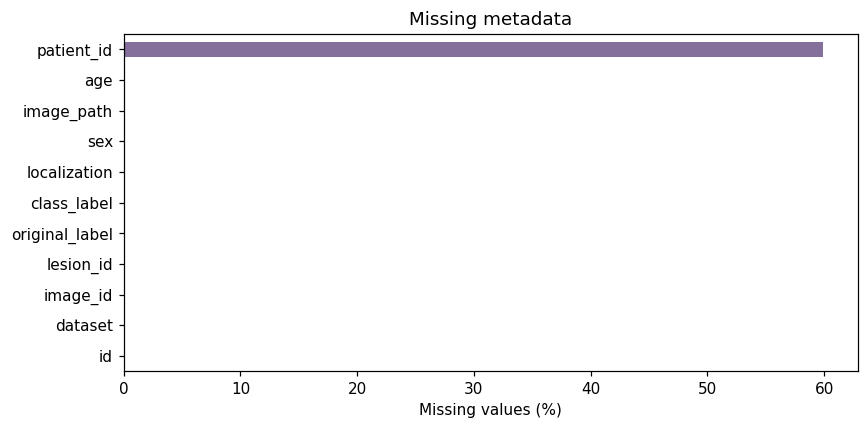

In [4]:
# Treat blank text as missing for this analysis only.
metadata = df.copy()
text_columns = metadata.select_dtypes(
    include=["object", "string"]
).columns

for column in text_columns:
    metadata[column] = metadata[column].replace(
        r"^\s*$", pd.NA, regex=True
    )

missing_summary = pd.DataFrame({
    "missing_count": metadata.isna().sum(),
    "missing_percentage": (
        metadata.isna().mean() * 100
    ).round(2)
})

print("Missing metadata:")
display(missing_summary)

print("Missing counts by dataset:")
display(
    metadata.groupby("dataset")[
        ["patient_id", "lesion_id", "age", "sex", "localization"]
    ].agg(lambda series: series.isna().sum())
)

identifier_duplicates = df.duplicated(
    ["dataset", "image_id"], keep=False
)
path_duplicates = df.duplicated(
    ["image_path"], keep=False
)

print(
    "Rows involved in repeated dataset/image identifiers:",
    int(identifier_duplicates.sum())
)
print(
    "Rows involved in repeated image paths:",
    int(path_duplicates.sum())
)

if identifier_duplicates.any():
    display(df.loc[identifier_duplicates])

if path_duplicates.any():
    display(df.loc[path_duplicates])

missing_summary.to_csv(
    OUTPUT_ROOT / "missing_metadata.csv"
)

fig, ax = plt.subplots(figsize=(8, 4))
missing_summary["missing_percentage"].sort_values().plot.barh(
    ax=ax, color="#84709b"
)
ax.set_title("Missing metadata")
ax.set_xlabel("Missing values (%)")
fig.tight_layout()
save_chart(fig, "02_missing_metadata.png")

In [5]:
lesion_sizes = (
    metadata.dropna(subset=["lesion_id"])
    .groupby(["dataset", "lesion_id"])
    .size()
    .rename("image_count")
    .reset_index()
)

patient_sizes = (
    metadata.dropna(subset=["patient_id"])
    .groupby(["dataset", "patient_id"])
    .size()
    .rename("image_count")
    .reset_index()
)

print("Lesions represented by multiple images:")
display(
    lesion_sizes[lesion_sizes["image_count"] > 1]
    .sort_values("image_count", ascending=False)
    .head(10)
)
print(
    "Number of lesions with multiple images:",
    int((lesion_sizes["image_count"] > 1).sum())
)

print("Patients represented by multiple images:")
display(
    patient_sizes[patient_sizes["image_count"] > 1]
    .sort_values("image_count", ascending=False)
    .head(10)
)
print(
    "Number of patients with multiple images:",
    int((patient_sizes["image_count"] > 1).sum())
)

lesion_sizes.to_csv(
    OUTPUT_ROOT / "images_per_lesion.csv", index=False
)
patient_sizes.to_csv(
    OUTPUT_ROOT / "images_per_patient.csv", index=False
)

Lesions represented by multiple images:


,dataset,lesion_id,image_count
227,HAM10000,HAM_0001863,6
905,HAM10000,HAM_0007343,5
928,HAM10000,HAM_0007558,4
339,HAM10000,HAM_0002824,4
450,HAM10000,HAM_0003700,4
548,HAM10000,HAM_0004621,4
437,HAM10000,HAM_0003602,4
1419,PAD-UFES-20,216,3
1410,PAD-UFES-20,202,3
584,HAM10000,HAM_0004878,3


Number of lesions with multiple images: 774
Patients represented by multiple images:


,dataset,patient_id,image_count
168,PAD-UFES-20,PAT_330,10
392,PAD-UFES-20,PAT_645,8
315,PAD-UFES-20,PAT_53,7
10,PAD-UFES-20,PAT_115,7
212,PAD-UFES-20,PAT_388,6
257,PAD-UFES-20,PAT_46,6
383,PAD-UFES-20,PAT_63,6
483,PAD-UFES-20,PAT_771,6
41,PAD-UFES-20,PAT_154,5
303,PAD-UFES-20,PAT_514,5


Number of patients with multiple images: 284


Recorded sex/gender values:


dataset,HAM10000,PAD-UFES-20
sex,,
FEMALE,0,524
MALE,0,565
female,621,0
male,1006,0


Age summary by dataset:


,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
HAM10000,1625.0,62.624615,14.993451,5.0,55.0,65.0,75.0,85.0
PAD-UFES-20,1089.0,63.996327,13.464413,21.0,55.0,64.0,74.0,94.0


Records with negative ages:


,dataset,image_id,age


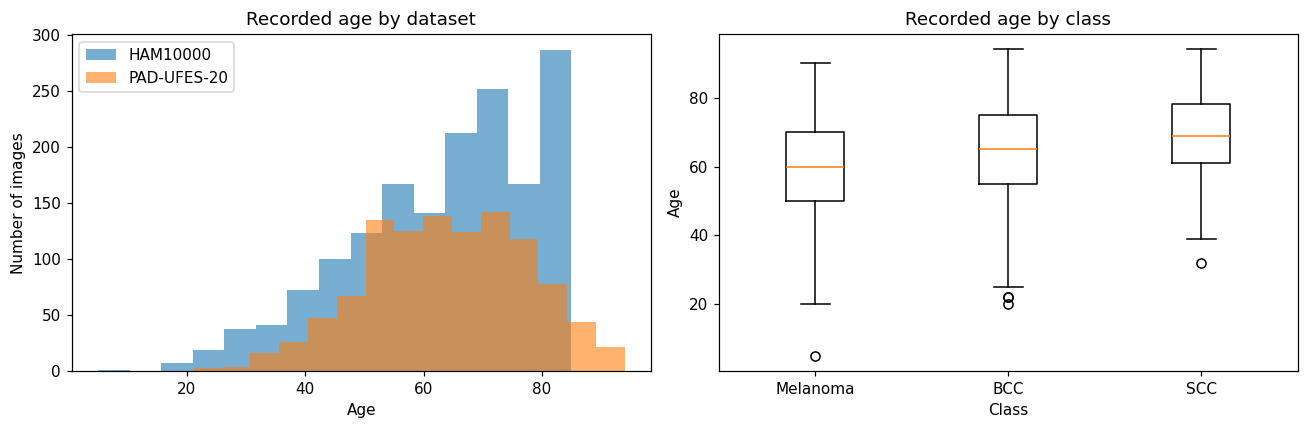

In [6]:
print("Recorded sex/gender values:")
sex_summary = pd.crosstab(
    metadata["sex"].fillna("(missing)"),
    metadata["dataset"]
)
display(sex_summary)

print("Age summary by dataset:")
age_summary = df.groupby("dataset")["age"].describe()
display(age_summary)

print("Records with negative ages:")
display(df.loc[
    df["age"] < 0,
    ["dataset", "image_id", "age"]
])

sex_summary.to_csv(
    OUTPUT_ROOT / "recorded_sex_values.csv"
)
age_summary.to_csv(
    OUTPUT_ROOT / "age_summary.csv"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for dataset in DATASET_ORDER:
    ages = df.loc[
        df["dataset"] == dataset, "age"
    ].dropna()

    if not ages.empty:
        axes[0].hist(
            ages, bins=15, alpha=0.6, label=dataset
        )

axes[0].set_title("Recorded age by dataset")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of images")
axes[0].legend()

age_groups = [
    df.loc[df["class_label"] == label, "age"].dropna()
    for label in CLASS_ORDER
]
available = [
    (label, values)
    for label, values in zip(CLASS_ORDER, age_groups)
    if not values.empty
]

if available:
    axes[1].boxplot([values for _, values in available])
    axes[1].set_xticks(range(1, len(available) + 1))
    axes[1].set_xticklabels([label for label, _ in available])

axes[1].set_title("Recorded age by class")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Age")

fig.tight_layout()
save_chart(fig, "03_age_distribution.png")

Checked 250/2716 images
Checked 500/2716 images
Checked 750/2716 images
Checked 1000/2716 images
Checked 1250/2716 images
Checked 1500/2716 images
Checked 1750/2716 images
Checked 2000/2716 images
Checked 2250/2716 images
Checked 2500/2716 images
Checked 2716/2716 images

Readable images: 2716
Images requiring investigation: 0


,dataset,image_id,class_label,width,height,mode,error


Image colour modes:


dataset,HAM10000,PAD-UFES-20
mode,,
RGB,1627,236
RGBA,0,853


Image dimensions:


width                                                       \
              count        mean         std    min    25%    50%     75%   
dataset                                                                    
HAM10000     1627.0  600.000000    0.000000  600.0  600.0  600.0   600.0   
PAD-UFES-20  1089.0  907.965106  481.553854  167.0  543.0  785.0  1165.0   

                     height                                               \
                max   count        mean         std    min    25%    50%   
dataset                                                                    
HAM10000      600.0  1627.0  450.000000    0.000000  450.0  450.0  450.0   
PAD-UFES-20  3096.0  1089.0  908.050505  481.463501  167.0  544.0  785.0   

                             
                75%     max  
dataset                      
HAM10000      450.0   450.0  
PAD-UFES-20  1165.0  3096.0

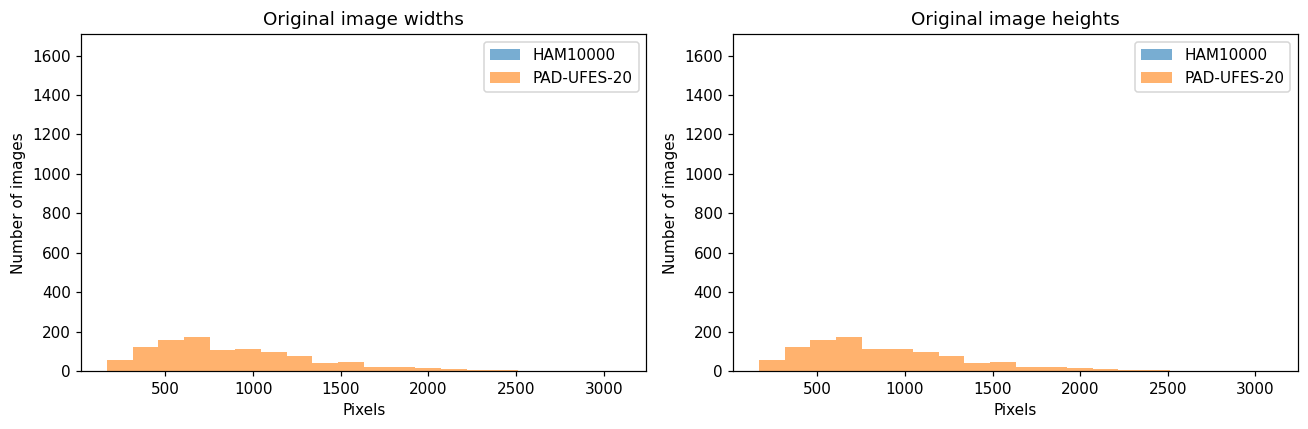

In [7]:
image_checks = []

for number, row in enumerate(
    df.itertuples(index=False), start=1
):
    result = {
        "dataset": row.dataset,
        "image_id": row.image_id,
        "class_label": row.class_label,
        "width": None,
        "height": None,
        "mode": None,
        "error": None,
    }

    try:
        with Image.open(row.image_path) as image:
            image.load()

            result.update({
                "width": image.width,
                "height": image.height,
                "mode": image.mode,
            })

    except Exception as exc:
        result["error"] = f"{type(exc).__name__}: {exc}"

    image_checks.append(result)

    if number % 250 == 0 or number == len(df):
        print(f"Checked {number}/{len(df)} images")

image_info = pd.DataFrame(image_checks)
valid_images = image_info[
    image_info["error"].isna()
].copy()
failed_images = image_info[
    image_info["error"].notna()
].copy()

image_info.to_csv(
    OUTPUT_ROOT / "image_properties.csv", index=False
)
failed_images.to_csv(
    OUTPUT_ROOT / "image_read_errors.csv", index=False
)

print("\nReadable images:", len(valid_images))
print("Images requiring investigation:", len(failed_images))
display(failed_images)

print("Image colour modes:")
display(pd.crosstab(
    valid_images["mode"], valid_images["dataset"]
))

print("Image dimensions:")
display(
    valid_images.groupby("dataset")[
        ["width", "height"]
    ].describe()
)

if not valid_images.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for dataset, group in valid_images.groupby("dataset"):
        axes[0].hist(
            group["width"], bins=20,
            alpha=0.6, label=dataset
        )
        axes[1].hist(
            group["height"], bins=20,
            alpha=0.6, label=dataset
        )

    axes[0].set_title("Original image widths")
    axes[1].set_title("Original image heights")

    for ax in axes:
        ax.set_xlabel("Pixels")
        ax.set_ylabel("Number of images")
        ax.legend()

    fig.tight_layout()
    save_chart(fig, "04_image_dimensions.png")

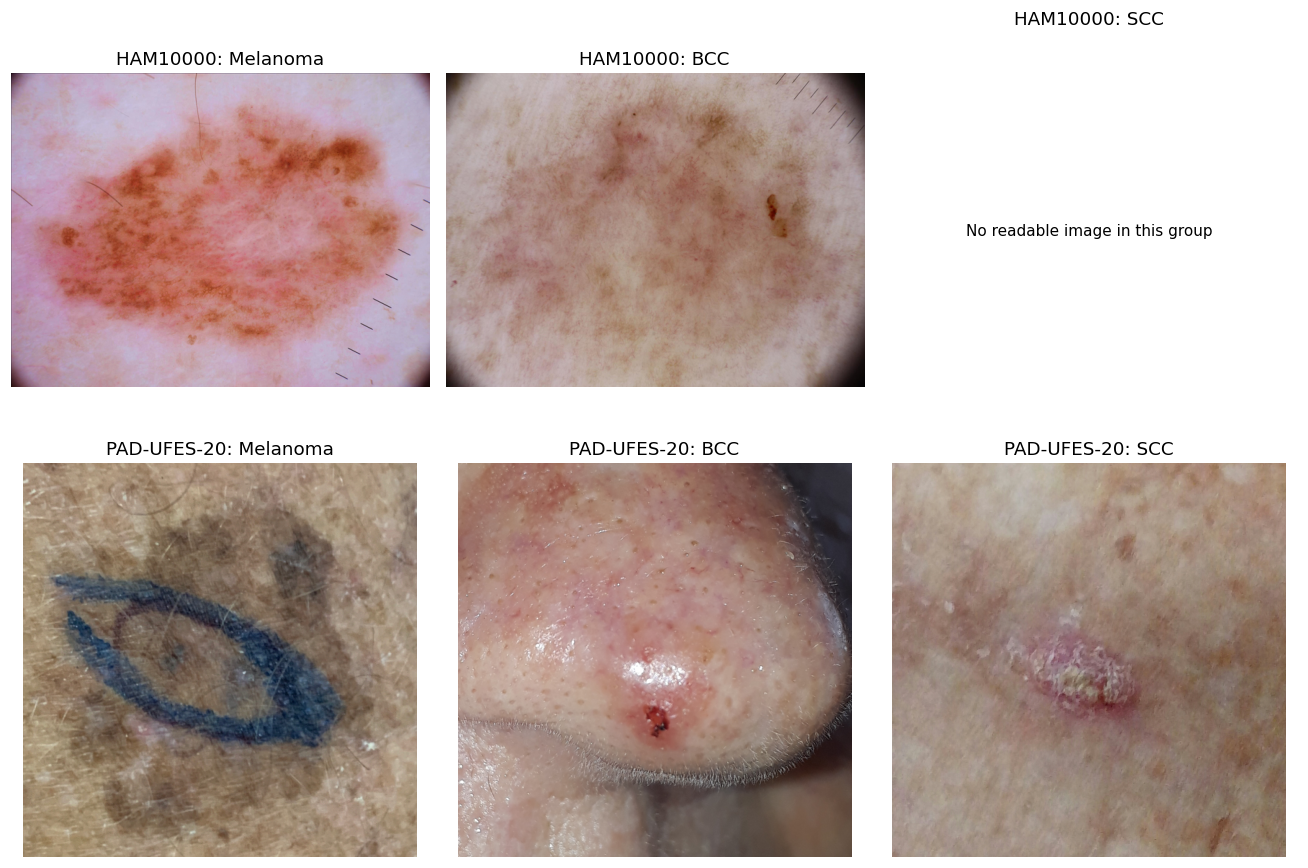

In [8]:
readable_df = df.merge(
    valid_images[["dataset", "image_id"]],
    on=["dataset", "image_id"],
    validate="one_to_one"
)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for row_index, dataset in enumerate(DATASET_ORDER):
    for col_index, label in enumerate(CLASS_ORDER):
        ax = axes[row_index, col_index]
        ax.axis("off")
        ax.set_title(f"{dataset}: {label}")

        subset = readable_df[
            (readable_df["dataset"] == dataset)
            & (readable_df["class_label"] == label)
        ]

        if subset.empty:
            ax.text(
                0.5, 0.5, "No readable image in this group",
                ha="center", va="center",
                transform=ax.transAxes
            )
            continue

        example = subset.sample(
            n=1, random_state=42
        ).iloc[0]

        with Image.open(example["image_path"]) as image:
            preview = ImageOps.exif_transpose(image).convert("RGB")
            ax.imshow(preview)

fig.tight_layout()
save_chart(fig, "05_representative_images.png")

In [9]:
PAD_ROOT = PROJECT_ROOT / "Datasets" / "PAD-UFES-20"
PAD_METADATA_PATH = PAD_ROOT / "metadata.csv"
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"
}

pad_metadata = pd.read_csv(PAD_METADATA_PATH)

pad_files = [
    path for path in PAD_ROOT.rglob("*")
    if path.is_file()
    and path.suffix.lower() in IMAGE_EXTENSIONS
]

reference_names = set(
    pad_metadata["img_id"]
    .dropna()
    .astype(str)
    .str.strip()
)
actual_names = {path.name for path in pad_files}

unreferenced_files = [
    str(path) for path in pad_files
    if path.name not in reference_names
]
missing_names = sorted(reference_names - actual_names)

print("PAD metadata rows:", len(pad_metadata))
print("PAD image files:", len(pad_files))

print("\nFiles not referenced by PAD metadata:")
display(pd.DataFrame({
    "image_path": unreferenced_files
}))

print("\nMetadata filenames not found on disk:")
display(pd.DataFrame({
    "image_id": missing_names
}))

pd.DataFrame({
    "image_path": unreferenced_files
}).to_csv(
    OUTPUT_ROOT / "pad_unreferenced_files.csv",
    index=False
)

pd.DataFrame({
    "image_id": missing_names
}).to_csv(
    OUTPUT_ROOT / "pad_missing_files.csv",
    index=False
)

PAD metadata rows: 2298
PAD image files: 2300

Files not referenced by PAD metadata:


,image_path
0,/content/drive/MyDrive/cnn-skin-cancer-classif...
1,/content/drive/MyDrive/cnn-skin-cancer-classif...



Metadata filenames not found on disk:


,image_id


In [10]:
for path in unreferenced_files:
    print(path)

/content/drive/MyDrive/cnn-skin-cancer-classification/Datasets/PAD-UFES-20/imgs_part_2/imgs_part_2/PAT_591_1126_21 (1).png
/content/drive/MyDrive/cnn-skin-cancer-classification/Datasets/PAD-UFES-20/imgs_part_1/imgs_part_1/PAT_379_4405_969 (1).png


## Findings and implications

### Class distribution
The database contains 2,716 selected images:
1,165 Melanoma, 1,359 BCC and 192 SCC.

SCC is substantially underrepresented. Later evaluation should
report per-class precision, recall and F1 scores alongside overall
accuracy. Any class weights should be calculated from training data.

### Dataset source
All selected SCC images come from PAD-UFES-20.
Source differences may influence predictions and require attention
during model evaluation.

### Missing metadata
HAM10000 does not provide patient IDs in the supplied metadata.
Missing patient IDs will remain missing.
Other missing demographic values and inconsistent text labels
will be reviewed during cleaning.

### Related images
Multiple images can belong to the same lesion or patient.
These related images should stay together during later splitting
to reduce data leakage.

### Image checks
Readable selected images: [enter result]
Images requiring investigation: [enter result]

Image dimensions and colour modes were inspected.
Resizing, model-specific preprocessing and training augmentation
will be implemented in the model pipeline.

### PAD file audit
PAD-UFES-20 contains 2,300 image files and 2,298 metadata records.
All metadata-referenced filenames were located. Two files have no
matching metadata record and were excluded from database ingestion.

### Limitations
This analysis covers only the three selected target classes.
Demographic summaries count images rather than unique people.
Identifier checks do not establish that all image content is unique.
This notebook does not measure model performance.

In [11]:
print("EDA ANALYSIS FINISHED")
print("Selected records:", len(df))
print("Readable selected images:", len(valid_images))
print("Image read errors:", len(failed_images))
print(
    "Repeated dataset/image identifier rows:",
    int(identifier_duplicates.sum())
)
print("Reports saved to:", OUTPUT_ROOT)

if not failed_images.empty:
    print("ACTION REQUIRED: investigate image read errors.")

print("\nSaved report files:")
for path in sorted(OUTPUT_ROOT.iterdir()):
    if path.is_file():
        print(path.name)

EDA ANALYSIS FINISHED
Selected records: 2716
Readable selected images: 2716
Image read errors: 0
Repeated dataset/image identifier rows: 0
Reports saved to: /content/drive/MyDrive/cnn-skin-cancer-classification/Reports/EDA

Saved report files:
01_class_distribution.png
02_missing_metadata.png
03_age_distribution.png
04_image_dimensions.png
05_representative_images.png
age_summary.csv
class_by_dataset.csv
class_distribution.csv
image_properties.csv
image_read_errors.csv
images_per_lesion.csv
images_per_patient.csv
missing_metadata.csv
pad_missing_files.csv
pad_unreferenced_files.csv
recorded_sex_values.csv
